# Análisis Exploratorio de Datos (EDA) - Accidentes de Tráfico en Madrid

## � Metadatos del Proyecto:

*Fecha del analisis :23-08-2025 

## -Dataset Link csv:
 https://datos.madrid.es/egob/catalogo/300228-28-accidentes-trafico-detalle.csv
 
## -Descripción de los datos:
https://datos.madrid.es/FWProjects/egob/Catalogo/Seguridad/Ficheros/Estructura_ConjuntoDatos_Accidentesv2dfpdfp

# Objetivo:
�-Realizar un análisis exploratorio que ayude a entender la naturaleza de los datos y preparar la información para su posterior uso en un modelo de Machine Learnni-

-Formular y responder a la siguiente pregunta de negocio relacionada con la información disponible: “¿En qué franja horaria se producen los accidentes con mayor gravedad (ingreso superior a 24 horas o fallecidos) y qué condiciones (estado meteorológico, tipo de accidente, etc.) pueden influir en ello-


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1- Tener una idea general de nuestro dataset y definir los tipos de datos que tenemos

#### Cargamos los datos

In [2]:
db=pd.read_csv("2024_Accidentalidad.csv", sep=";")

#### Inspeccionar la forma del dataframe

In [3]:
db.shape

(49340, 19)

In [4]:
db.head()

,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorológico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga
0,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Motocicleta > 125cc,Conductor,De 55 a 59 años,Hombre,2.0,Ingreso inferior o igual a 24 horas,444913.0,4481427.0,N,NaN
1,2023S040280,04/01/2024,14:09:00,AVDA. NICETO ALCALA ZAMORA / AUTOV. M-11,3,16,HORTALEZA,Colisión fronto-lateral,Lluvia débil,Turismo,Conductor,De 55 a 59 años,Mujer,14.0,Sin asistencia sanitaria,444913.0,4481427.0,N,NaN
2,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Bicicleta,Conductor,De 25 a 29 años,Hombre,7.0,Asistencia sanitaria sólo en el lugar del acci...,440123.0,4475170.0,N,NaN
3,2023S040309,15/02/2024,14:05:00,CALL. TESORO / CALL. MINAS,18,1,CENTRO,Colisión fronto-lateral,Lluvia débil,Motocicleta hasta 125cc,Conductor,De 35 a 39 años,Hombre,14.0,Sin asistencia sanitaria,440123.0,4475170.0,N,NaN
4,2023S040310,18/02/2024,10:40:00,GTA. RUIZ JIMENEZ / CALL. SAN BERNARDO,3,7,CHAMBERÍ,Colisión lateral,Despejado,Turismo,Conductor,De 25 a 29 años,Hombre,NaN,NaN,440137.0,4475721.0,N,NaN


#### Revisar las columnas y los tipos de datos de cada columna

In [5]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49340 entries, 0 to 49339
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_expediente        49340 non-null  object 
 1   fecha                 49340 non-null  object 
 2   hora                  49340 non-null  object 
 3   localizacion          49340 non-null  object 
 4   numero                49340 non-null  object 
 5   cod_distrito          49340 non-null  int64  
 6   distrito              49340 non-null  object 
 7   tipo_accidente        49335 non-null  object 
 8   estado_meteorológico  43424 non-null  object 
 9   tipo_vehiculo         48946 non-null  object 
 10  tipo_persona          49340 non-null  object 
 11  rango_edad            49340 non-null  object 
 12  sexo                  49340 non-null  object 
 13  cod_lesividad         27344 non-null  float64
 14  lesividad             27344 non-null  object 
 15  coordenada_x_utm   

In [6]:
db.columns

Index(['num_expediente', 'fecha', 'hora', 'localizacion', 'numero',
       'cod_distrito', 'distrito', 'tipo_accidente', 'estado_meteorológico',
       'tipo_vehiculo', 'tipo_persona', 'rango_edad', 'sexo', 'cod_lesividad',
       'lesividad', 'coordenada_x_utm', 'coordenada_y_utm', 'positiva_alcohol',
       'positiva_droga'],
      dtype='object')

# 2- Limpieza de datos y tratamiento de valores nulos:

#### Identificar columnas con valores faltantes (“NULL”, “NaN”, etc.)

In [7]:
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              5
estado_meteorológico     5916
tipo_vehiculo             394
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad           21996
lesividad               21996
coordenada_x_utm            6
coordenada_y_utm            6
positiva_alcohol          167
positiva_droga          49137
dtype: int64

# Manejo de valores nulos
tipo_accidente 5 nulos muy pocos, lo mas sencillo es eliminarlas

In [8]:
db = db[~db["tipo_accidente"].isnull()]
db["tipo_accidente"].isnull().sum()

0

estado_meteorológico tiene 5,911 valores nulos,
no es correcto imputar condiciones meteorologicas inexistentes, porque seria inventar informacion.
Decision: Sustituir los valores nulos como una nueva categoria llamada "Desconocido"

In [9]:
#Ver cuantos nulos hay
db['estado_meteorológico'].isnull().sum()

5911

In [10]:
#Sustituir nulos por "Desconocido"
db['estado_meteorológico'] = db['estado_meteorológico'].fillna("Desconocido")

#Verificar que ya no quedan nulos
db['estado_meteorológico'].isna().sum()

0

In [11]:
#Revisar cuantos valores tiene cada categoria
db['estado_meteorológico'].value_counts()

estado_meteorológico
Despejado         36735
Desconocido        5911
Nublado            3464
Lluvia débil       2395
LLuvia intensa      464
Se desconoce        356
Granizando            8
Nevando               2
Name: count, dtype: int64

#### tipo_vehiculo tiene 394 valores nulos

Decision: igual que antes Sustituir los valores nulos com una nueva categoria “Sin_info”

In [12]:
#Ver cuantos nulos hay
db['tipo_vehiculo'].isnull().sum()

394

In [13]:
#Sustituir nulos por "Sin_info"
db['tipo_vehiculo'] = db['tipo_vehiculo'].fillna("Sin_info")

#Verificar que ya no quedan nulos
db['tipo_vehiculo'].isnull().sum()

0

In [14]:
#Revisar cuantos valores tiene cada categoria
db['tipo_vehiculo'].value_counts()

tipo_vehiculo
Turismo                              33870
Motocicleta hasta 125cc               3308
Furgoneta                             3236
Motocicleta > 125cc                   1805
Autobús                               1501
Camión rígido                         1164
Todo terreno                           829
Bicicleta                              812
VMU eléctrico                          771
Ciclomotor                             471
Sin_info                               394
Bicicleta EPAC (pedaleo asistido)      264
Tractocamión                           212
Maquinaria de obras                    182
Otros vehículos con motor              164
Vehículo articulado                     84
Autobús articulado                      78
Cuadriciclo ligero                      42
Sin especificar                         37
Autobus EMT                             27
Cuadriciclo no ligero                   19
Ciclo                                   17
Autocaravana                            

#### lesividad y cod_lesividad tienen 21993 nulos, Segun el PDF estos valores en blanco equivalen a "sin asistencia sanitaria", por lo que no deben eliminarse ni imputarse con medias.

Decision: reemplazar nulos por "Sin asistencia sanitaria", mantener 77 como "Desconocido" y crear una variable gravedad con tres niveles: Leve, Grave, Fallecido.

In [15]:
db['lesividad'].isnull().sum() & db['cod_lesividad'].isnull().sum()

21993

In [16]:
# Reemplazar nulos en 'lesividad' y 'cod_lesividad' con "Sin asistencia sanitaria"
db['lesividad'] = db['lesividad'].fillna("Sin asistencia sanitaria")
db['cod_lesividad'] = db['cod_lesividad'].fillna("14")

In [17]:
#Mapear cod_lesividad a gravedad
map_gravedad = {
    "01": "LEVE",
    "02": "LEVE",
    "05": "LEVE",
    "06": "LEVE",
    "07": "LEVE",
    "03": "GRAVE",
    "04": "FALLECIDO",
    "14": "Sin asistencia sanitaria",
    "77": "Desconocido"
}

# Ver todos los valores unicos de cod_lesividad
print(db['cod_lesividad'].unique())

#Normalizar cod_lesividad
'''
Se convierten los codigos a string de dos digitos y se reemplazan los nulos con "14".
Esto asegura que los codigos coincidan con el diccionario oficial y se puedan mapear correctamente a la columna gravedad.
'''

db['cod_lesividad'] = db['cod_lesividad'].fillna(14).astype(int).astype(str).str.zfill(2)

#Crear nueva columna 'gravedad' aplicando el mapeo
db['gravedad'] = db['cod_lesividad'].map(map_gravedad)


# 4.Comprobar distribucion de categorias
db['gravedad'].value_counts()

[2.0 14.0 7.0 '14' 1.0 3.0 6.0 5.0 4.0 77.0]


gravedad
Sin asistencia sanitaria    38108
LEVE                        10629
GRAVE                         567
FALLECIDO                      29
Desconocido                     2
Name: count, dtype: int64

In [18]:
#Verificar que ya no quedan nulos
db['lesividad'].isnull().sum() & db['cod_lesividad'].isnull().sum()
db['gravedad'].isnull().sum()

0

In [19]:
db.isnull().sum()

num_expediente              0
fecha                       0
hora                        0
localizacion                0
numero                      0
cod_distrito                0
distrito                    0
tipo_accidente              0
estado_meteorológico        0
tipo_vehiculo               0
tipo_persona                0
rango_edad                  0
sexo                        0
cod_lesividad               0
lesividad                   0
coordenada_x_utm            5
coordenada_y_utm            5
positiva_alcohol          167
positiva_droga          49133
gravedad                    0
dtype: int64

#### coordenada_x_utm y coordenada_y_utm son coordenadas de ubicacion, no podemos inventarlas.
Decision: como son muy pocos casos, lo mas limpio es eliminar esas filas.

In [20]:
db = db.dropna(subset= ['coordenada_x_utm', 'coordenada_y_utm'])

In [21]:
db['coordenada_x_utm'].isnull().sum() & db['coordenada_y_utm'].isnull().sum()

0

#### positiva_alcohol tiene 167 nulos, y segun el pdf puede ser N o S.
Decision: no rellenar con "N" ni "S", porque seria inventar resultados.
Creamos categoria "Desconocido".

In [22]:
db['positiva_alcohol'] = db['positiva_alcohol'].fillna("Desconocido")

In [23]:
#Verificar que ya no quedan nulos
db['positiva_alcohol'].isna().sum()

0

In [24]:
#Revisar cuantos valores tiene cada categoria
db['positiva_alcohol'].value_counts()

positiva_alcohol
N              47730
S               1433
Desconocido      167
Name: count, dtype: int64

positiva_droga segun el pdf puede ser null o 1.
Decision: reemplazar los nulos con "0" para representar “no positivo / no registrado”.
Mantener "1" como positivo.

In [25]:
db['positiva_droga'] = db['positiva_droga'].fillna(0).astype(int)

In [26]:
#Verificar que ya no quedan nulos
db['positiva_droga'].isna().sum()

0

In [27]:
#Revisar cuantos valores tiene cada categoria
db['positiva_droga'].value_counts()

positiva_droga
0    49128
1      202
Name: count, dtype: int64

### 3- Descripción estadística de los datos y visualización

### 1/3 Analisis univariado de variables categoricas

#### en esta parte del análisis lo que hicimos fue evitar el doble conteo de accidentes. en el dataset, cada accidente (num_expediente) puede aparecer varias veces porque hay varios implicados.

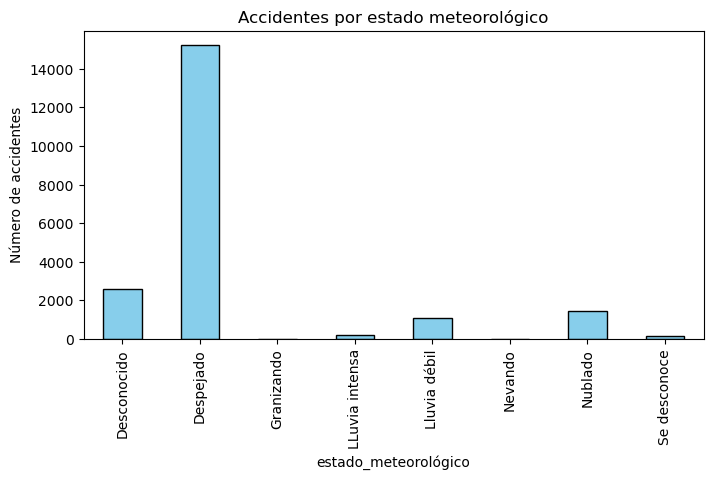

In [28]:
#1.Estado meteorológico
db[['num_expediente','estado_meteorológico']].drop_duplicates() \
    .groupby('estado_meteorológico').size().plot(
        kind="bar", figsize=(8,4), color="skyblue", edgecolor="black"
    )
plt.title("Accidentes por estado meteorológico")
plt.ylabel("Número de accidentes")
plt.show()

##### La mayoria de los accidentes se producen con cielo despejado. Esto sugiere que las condiciones adversas (lluvia, nieve) no son la causa principal, probablemente porque en dias despejados hay mucho trafico.

### 2.Tipo de accidente

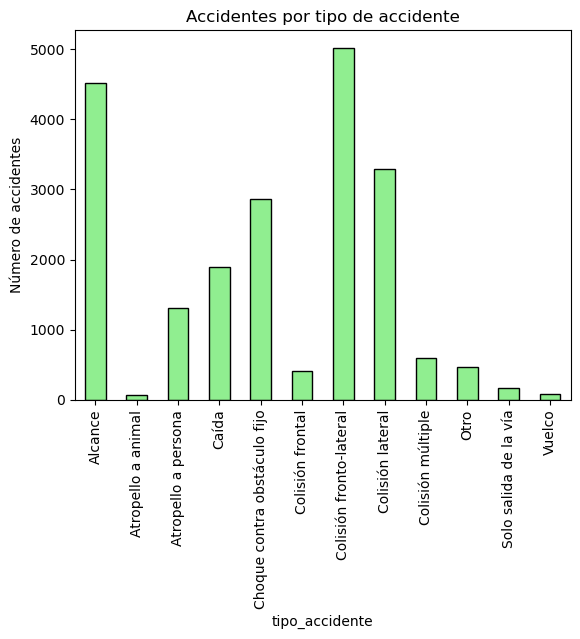

In [29]:
db[['num_expediente','tipo_accidente']].drop_duplicates() \
    .groupby('tipo_accidente').size().plot(
        kind="bar", color="lightgreen", edgecolor="black"
    )
plt.title("Accidentes por tipo de accidente")
plt.ylabel("Número de accidentes")
plt.xticks(rotation=90)
plt.show()

Las colisiones entre vehiculos son los accidentes mas frecuentes, lo que confirma que la interaccion entre coches es el principal riesgo en ciudad.

### 3.Sexo

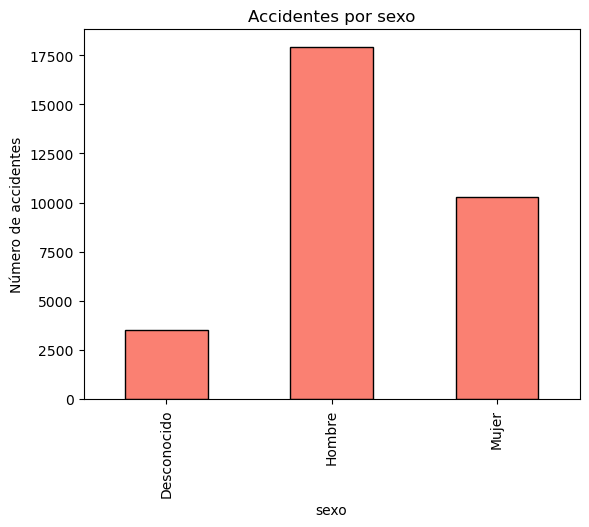

In [30]:
db[['num_expediente','sexo']].drop_duplicates() \
    .groupby('sexo').size().plot(
        kind="bar", color="salmon", edgecolor="black"
    )
plt.title("Accidentes por sexo")
plt.ylabel("Número de accidentes")
plt.show()

Los hombres aparecen mas involucrados en accidentes que las mujeres. Esto puede estar relacionado con un mayor numero de conductores hombres.

### 4.Distrito

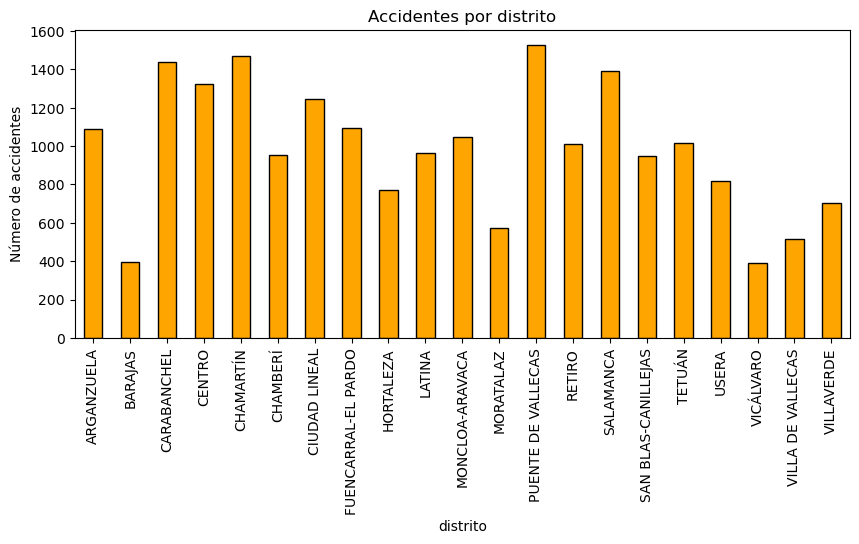

In [31]:
db[['num_expediente','distrito']].drop_duplicates() \
    .groupby('distrito').size().plot(
        kind="bar", figsize=(10,4), color="orange", edgecolor="black"
    )
plt.title("Accidentes por distrito")
plt.ylabel("Número de accidentes")
plt.xticks(rotation=90)
plt.show()

Los distritos centricos presentan mas accidentes, lo que refleja la intensidad del trafico en esas zonas

### 2/3 Analisis univariado de variables numéricas

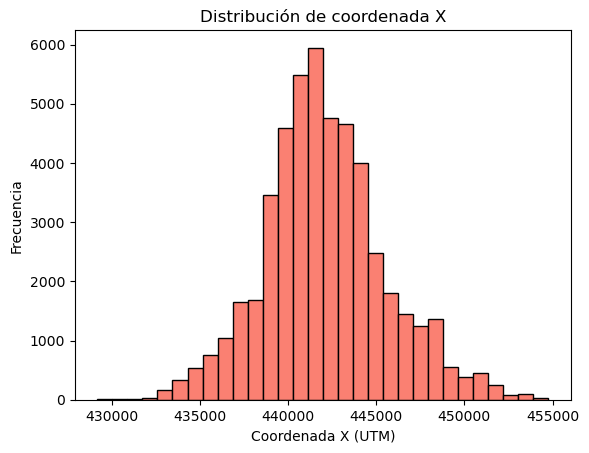

In [32]:
#Coordenada X 
plt.hist(db['coordenada_x_utm'], bins=30, color='salmon', edgecolor='black')
plt.xlabel('Coordenada X (UTM)')
plt.ylabel('Frecuencia')
plt.title('Distribución de coordenada X')
plt.show()

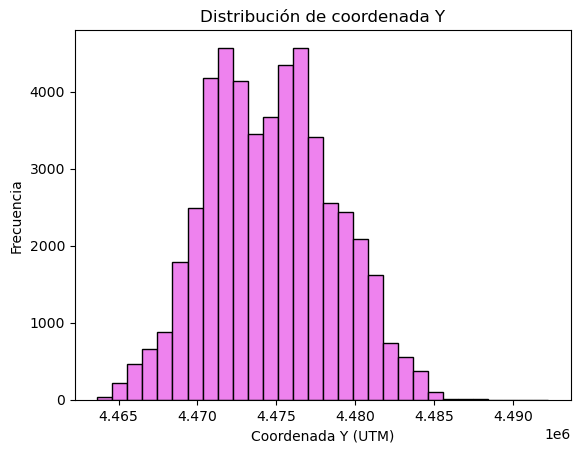

In [33]:
#Coordenada Y
plt.hist(db['coordenada_y_utm'], bins=30, color='violet', edgecolor='black')
plt.xlabel('Coordenada Y (UTM)')
plt.ylabel('Frecuencia')
plt.title('Distribución de coordenada Y')
plt.show()

### 4-Analizar las posibles interacciones entre las variables del dataset

#### Analisis bivariado

##### 1-Hora vs Tipo de Accidente

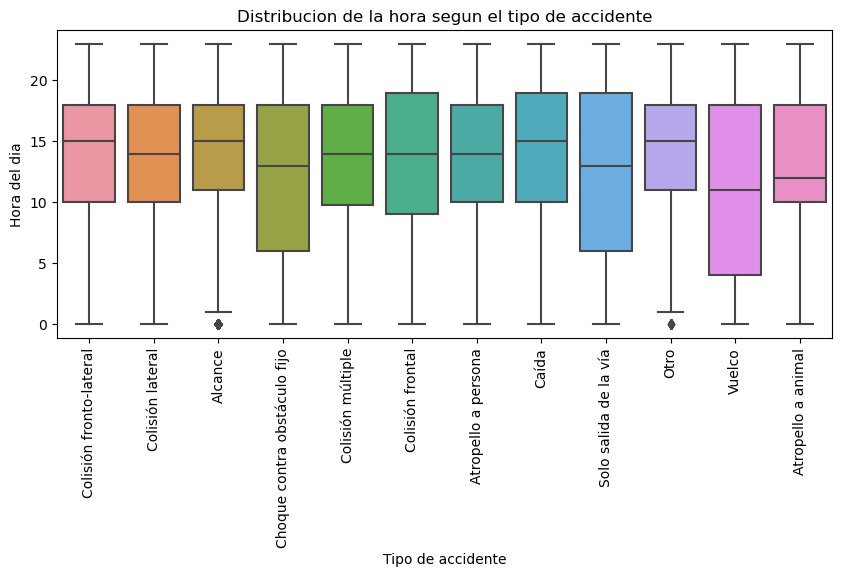

In [34]:
#convertir hora a número entero
db["hora_num"] = pd.to_datetime(db["hora"], format="%H:%M:%S" ).dt.hour

plt.figure(figsize=(10,4))
sns.boxplot(x="tipo_accidente", y="hora_num", data=db)
plt.xticks(rotation=90)
plt.title("Distribucion de la hora segun el tipo de accidente")
plt.xlabel("Tipo de accidente")
plt.ylabel("Hora del dia")
plt.show()

Los distintos tipos de accidente muestran distribuciones horarias similares, aunque ciertos accidentes (como atropellos) parecen mas comunes en horas de tarde.

2- tipo de accidente vs gravedad

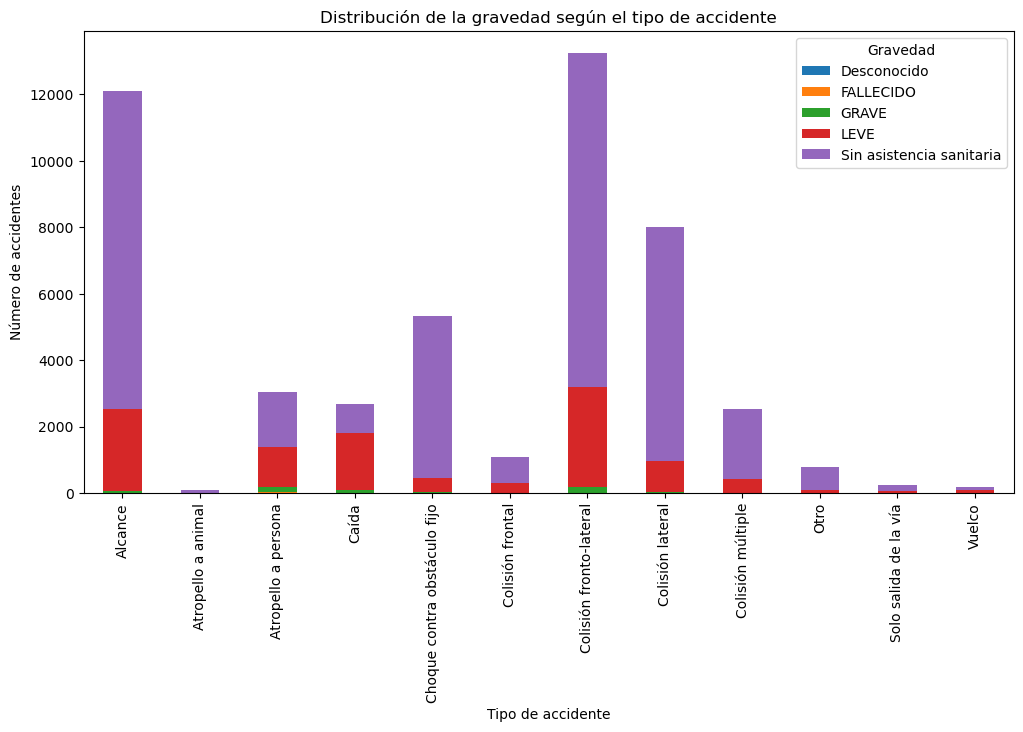

In [35]:
# Agrupar por tipo de accidente y gravedad
grupo = db.groupby(["tipo_accidente", "gravedad"]).size().reset_index(name="conteo")

# Pivotear para crear formato de tabla
pivot = grupo.pivot(index="tipo_accidente", columns="gravedad", values="conteo")

pivot.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Distribución de la gravedad según el tipo de accidente")
plt.xlabel("Tipo de accidente")
plt.ylabel("Número de accidentes")
plt.xticks(rotation=90)
plt.legend(title="Gravedad")
plt.show()

Esta gráfica muestra cómo varía la gravedad de los accidentes según el tipo de accidente. En general, la mayoría de los casos terminan en lesiones leves, aunque ciertos tipos de accidentes presentan más casos graves. Esto permite identificar qué situaciones son más críticas en términos de severidad.

3- hora vs gravedad

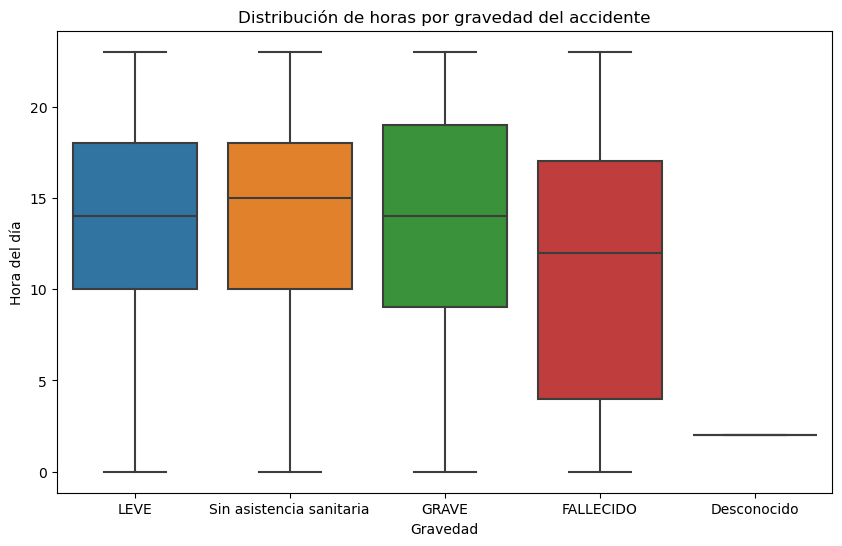

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(x="gravedad", y="hora_num", data=db)
plt.title("Distribución de horas por gravedad del accidente")
plt.xlabel("Gravedad")
plt.ylabel("Hora del día")
plt.show()

Los accidentes graves y mortales aparecen con mas frecuencia en la madrugada y primeras horas de la mañana. Esto puede estar relacionado con menor visibilidad, sueño, fatiga o consumo de alcohol.

# 5- Categoría adicional

### 1- Análisis de correlaciones

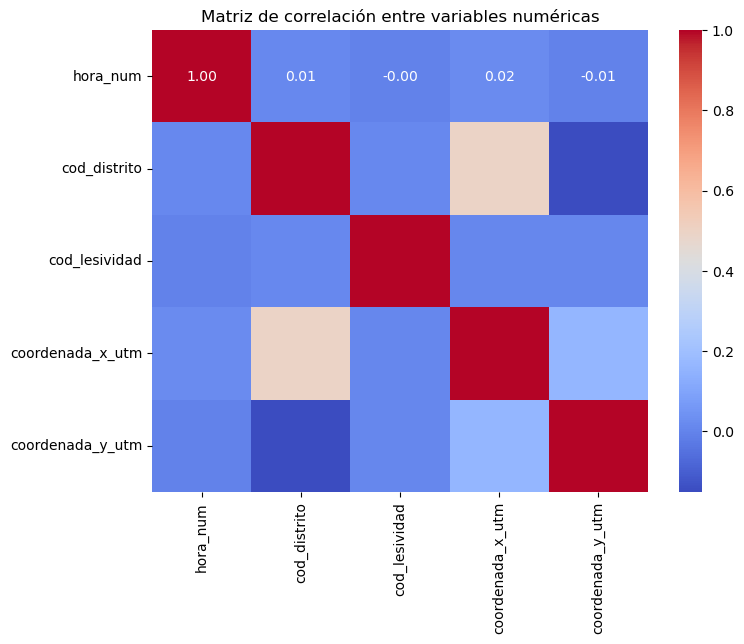

In [37]:
# Seleccionamos solo variables numéricas relevantes
num_cols = ["hora_num", "cod_distrito", "cod_lesividad",
            "coordenada_x_utm", "coordenada_y_utm"]

# Calculo de la matriz de correlación
corr = db[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

No se observan correlaciones fuertes entre las variables numericas, lo que indica que cada una aporta informacion distinta al análisis.

### 2- Estudio de la temporalidad con series de tiempo

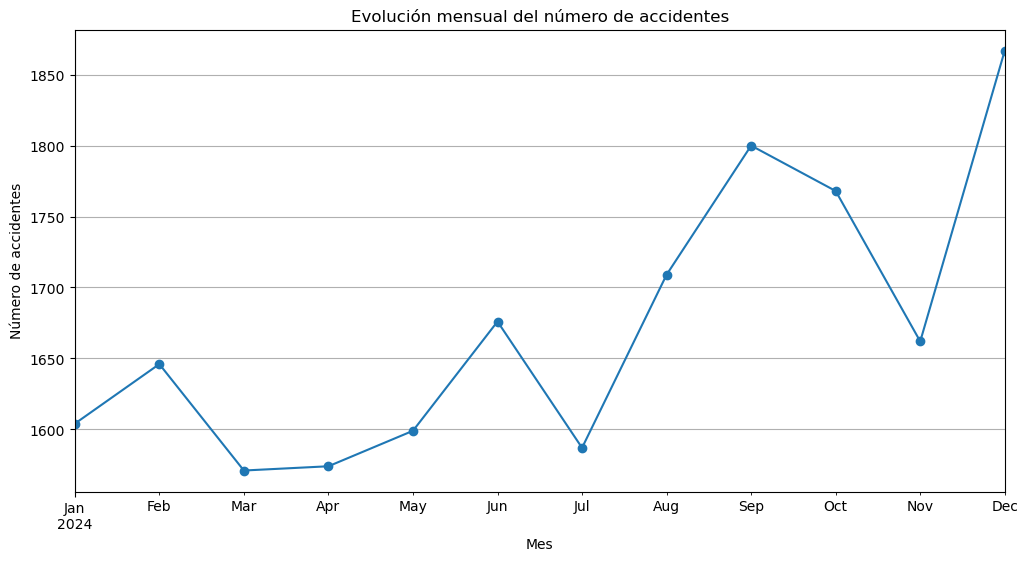

In [38]:
# Convertir fecha a datetime
db["fecha"] = pd.to_datetime(db["fecha"], errors="coerce")

# Agrupar por mes
accidentes_por_mes = db.groupby(db["fecha"].dt.to_period("M")).size()

plt.figure(figsize=(12,6))
accidentes_por_mes.plot(kind="line", marker="o")
plt.title("Evolución mensual del número de accidentes")
plt.xlabel("Mes")
plt.ylabel("Número de accidentes")
plt.grid(True)
plt.show()

Los accidentes muestran cierta variación mensual, lo que puede estar relacionado con factores estacionales (clima, vacaciones)

# - Resumen final del EDA

## - Durante el análisis exploratorio del dataset de accidentalidad hemos realizado los siguientes pasos y hallazgos:

### Limpieza y preparación de datos:

- Se detectaron duplicados en num_expediente, que fueron eliminados para evitar sobre-representación.

- Se transformaron variables de texto a numéricas (la hora → hora_num) y las fechas a formato datetime.

#### 1- Análisis univariante

- Identificamos los tipos de accidente más comunes, la distribución por sexo, estado meteorológico y distritos.

- Se observó que muchos accidentes ocurren en condiciones de tiempo despejado y sin asistencia sanitaria requerida.

#### 2- Análisis bivariante

1. Hora vs tipo de accidente: Hay patrones horarios claros en ciertos tipos de accidente.

2. Estado meteorológico vs lesividad: La mayoría de accidentes en días despejados suelen ser leves o sin asistencia.

3. Hora vs gravedad: Accidentes graves aparecen en horarios nocturnos y de madrugada con más frecuencia relativa.

#### 4- Análisis adicional

- Correlaciones: No se observan correlaciones fuertes entre variables numéricas, lo que indica que aportan información independiente.

- Temporalidad: Existen fluctuaciones mensuales en los accidentes, lo que sugiere cierta estacionalidad ligada a clima o movilidad.

# Responder a la pregunta de negocio inicial:

1. Franja horaria
Los accidentes con mayor gravedad se concentran principalmente en la madrugada y primeras horas de la mañana (00:00 - 06:00). Durante las horas del día (08:00 - 20:00) predominan los accidentes leves o sin asistencia sanitaria.

2. Estado meteorológico
La mayoría de los accidentes graves ocurren en condiciones meteorológicas despejadas, lo que indica que el clima no es un factor determinante en la gravedad. Los accidentes con lluvia o nieve son menos frecuentes y no muestran una incidencia especialmente más grave.

3. Tipo de accidente
Los tipos de accidente más asociados a casos graves son los atropellos a peatones y las colisiones múltiples. En cambio, en los accidentes leves predominan los alcances y colisiones simples.

4. Factores influyentes
La franja nocturna coincide con una mayor probabilidad de consumo de alcohol y drogas y con menor visibilidad, lo que puede explicar la mayor severidad.

## Conclusión:

La franja horaria más crítica es la madrugada (00:00 - 06:00), en la que se concentran los accidentes con consecuencias más graves. Esto sugiere que las campañas de prevención y vigilancia deberían focalizarse en los controles de alcohol y drogas en horario nocturno, el refuerzo de la iluminación y señalización en vías urbanas.

En resumen, no es el mal clima el que más influye en la gravedad de los accidentes, sino factores ligados al comportamiento humano y a la franja horaria nocturna.